# **VERIFICATION THRESHOLD**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys

!pip install facenet-pytorch

src_path = "/content/drive/MyDrive/11/Consegna finale/src"

if src_path not in sys.path:
    sys.path.append(src_path)

import os
import torch
from sklearn.model_selection import train_test_split
from verification_system import VerificationSystem

## **Valutazione Sistema di Verifica (Verification)**

Questa sezione esegue il benchmarking del sistema nello scenario **1:1** (Verifica dell'Identità). L'obiettivo è determinare se il soggetto è *chi dice di essere*, confrontando il suo volto (Probe) con quello registrato in Gallery.

Il processo segue una rigorosa separazione dei dati per evitare **Data Leakage**:
1.  **Caricamento Gallery:** Vengono recuperati gli embeddings di riferimento generati durante l'enrollment.
2.  **Calcolo Soglia (Validation Set):**
    * Il dataset di Probes viene diviso: 40% per la validazione, 60% per il test.
    * Sul set di validazione vengono calcolate le distanze tra coppie *Genuines* (stessa persona) e *Impostors* (persone diverse).
    * Viene generata la curva **ROC**  per trovare la **Soglia $T_v$** ottimale al punto di **EER (Equal Error Rate)**.
3.  **Test Finale (Test Set):**
    * La soglia $T_v$ viene congelata e applicata al restante 60% dei dati (mai visti durante il calcolo della soglia).
    * Vengono misurate le metriche reali: **Rank-1 Accuracy**, **FAR** (False Acceptance Rate) e **FRR** (False Rejection Rate).

In [ ]:
def get_probe_split_helper(probes_root_path, val_size=0.4, random_seed=42):
    """
    Replica ESATTAMENTE la logica di caricamento della classe per garantire
    che il Test Set sia identico a quello escluso durante il calcolo della soglia.
    """
    all_files = []
    all_labels = []

    if not os.path.exists(probes_root_path): return [], [], [], []

    subject_dirs = sorted([d for d in os.listdir(probes_root_path) if os.path.isdir(os.path.join(probes_root_path, d))])

    for subject_dir in subject_dirs:
        subject_path = os.path.join(probes_root_path, subject_dir)
        if "subject_" in subject_dir:
            try:
                label = int(subject_dir.split('_')[1])
                files = sorted([f for f in os.listdir(subject_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

                for fname in files:
                    all_files.append(os.path.join(subject_path, fname))
                    all_labels.append(label)
            except:
                continue

    if not all_files: return [], [], [], []

    return train_test_split(
        all_files, all_labels,
        test_size=(1 - val_size),
        stratify=all_labels,
        random_state=random_seed
    )

--- Esecuzione Verification su: cpu ---
Inizializzazione Modello su cpu...
ATTENZIONE: Nessun peso custom trovato/fornito. Uso VGGFace2 standard.

Caricamento Gallery da file: features_labels_gr_11 e features_embeddings_gr_11...
Gallery caricata: 160 soggetti.

--- Inizio Calcolo Soglie (Val Split: 0.4) ---
Totale Probes: 359
Validation Set (usato per ROC/Soglia): 143
Test Set (DA SALVARE/USARE DOPO): 216
Estrazione features validation set in corso...
Calcolo matrice distanze (Batch)...

=== RISULTATI SOGLIA (Tv) ===
Soglia EER: 0.7916 (EER: 0.70%)


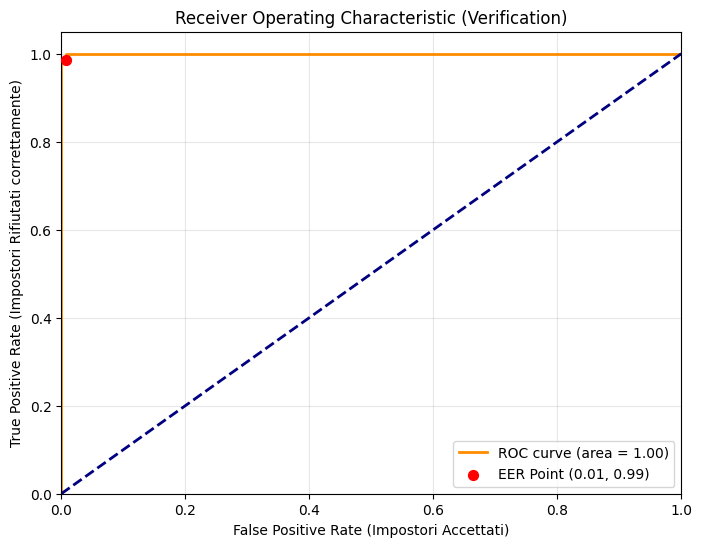


Recupero Test Set separato...

--- VALUTAZIONE TEST SET (216 campioni) ---
Estrazione feature Test Set...
Tempo estrazione: 204.12s

 RISULTATI FINALI SUL TEST SET
Soglia usata (Tv): 0.7916
----------------------------------------
Rank-1 Identification Rate: 99.54%
----------------------------------------
False Acceptance Rate (FAR): 0.00%
False Rejection Rate  (FRR): 0.46%

[FINE] Soglia Tv salvata in memoria: 0.7916


In [ ]:
PATH_GALLERY_EMB_PREFIX = "features_embeddings_gr_11"
PATH_GALLERY_LBL_PREFIX = "features_labels_gr_11"
PATH_PROBES_DIR = "/content/drive/MyDrive/BBA_Dataset_processed/probes"


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"--- Esecuzione Verification su: {device} ---")

fr_system = VerificationSystem(device)

if os.path.exists(f"{PATH_GALLERY_EMB_PREFIX}.npy") and os.path.exists(f"{PATH_GALLERY_LBL_PREFIX}.npy"):
    fr_system.load_existing_gallery(PATH_GALLERY_EMB_PREFIX, PATH_GALLERY_LBL_PREFIX)
else:
    print(f"ERRORE: Gallery non trovata.")
    exit()

if os.path.exists(PATH_PROBES_DIR):
    best_tv = fr_system.compute_validation_thresholds(
        probes_root_dir=PATH_PROBES_DIR,
        val_split=0.4,
        random_seed=42
    )

    if best_tv is not None:
        print("\nRecupero Test Set separato...")
        _, X_test, _, y_test = get_probe_split_helper(
            PATH_PROBES_DIR,
            val_size=0.4,
            random_seed=42
        )

        fr_system.evaluate_test_set(X_test, y_test, best_tv)

        print(f"\n[FINE] Soglia Tv salvata in memoria: {best_tv:.4f}")
else:
    print("Path probes errato.")